In [4]:
import numpy as np
import pandas as pd
from numpy import linalg as LA
import matplotlib.pyplot as plt
import matplotlib.patches as patches

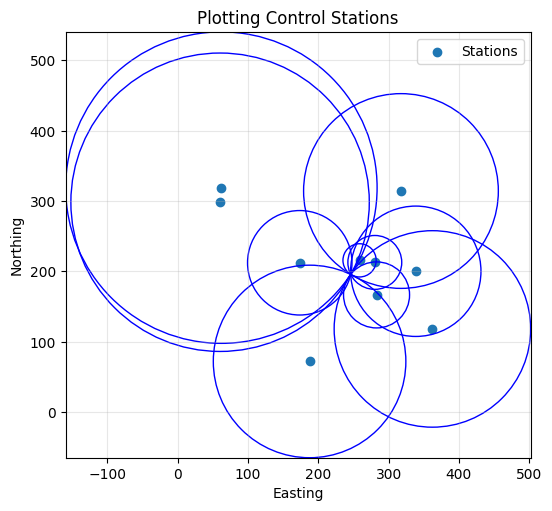

File saved as ctrlPoints_normalSpaces.txt


In [5]:
coords = pd.read_table('ctrlPoints_2026.txt', header=None)
coords = coords.dropna(axis=1)
coords.columns = range(coords.shape[1])
radius = pd.read_table('distObs_2026.txt', header=None)

r = radius.iloc[:,0]
x = coords.iloc[:,0]
y = coords.iloc[:,1]

fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
ax.scatter(x, y, label='Stations')
for i in range(len(coords)):
    circle = patches.Circle((x[i], y[i]), float(r[i]), color='blue', fill=False, linewidth=1)
    ax.add_patch(circle)
ax.set_aspect('equal', adjustable='box')
ax.autoscale(enable=True, tight=True)
ax.set_xlabel("Easting"); ax.set_ylabel("Northing"); ax.set_title("Plotting Control Stations")
ax.grid(True, alpha=.3); ax.legend();
plt.show()

coords.to_csv('ctrlPoints_normalSpaces.txt', sep='\t', header=False, index=False)
print('File saved as ctrlPoints_normalSpaces.txt')

In [6]:
az = pd.read_table('azObs_2026.txt', header=None)
az = az.dropna(axis=1)
az.columns = range(az.shape[1])
az_ddeg = []
for i in range(len(az)):
    deg = az.iloc[i,0]
    min = az.iloc[i,1]
    sec = az.iloc[i,2]
    az_ddeg = (az[0] + az[1]/60 + az[2]/3600)
#print(az_ddeg)
az_rad = np.deg2rad(az_ddeg)
az_rad.to_csv('az_rad.txt', sep='\t', header=False, index=False)
print('File saved as az_rad.txt')
maxW = np.rad2deg(2.227e-4)
maxWsec = maxW*3600
print(maxWsec)

File saved as az_rad.txt
45.93517235122836


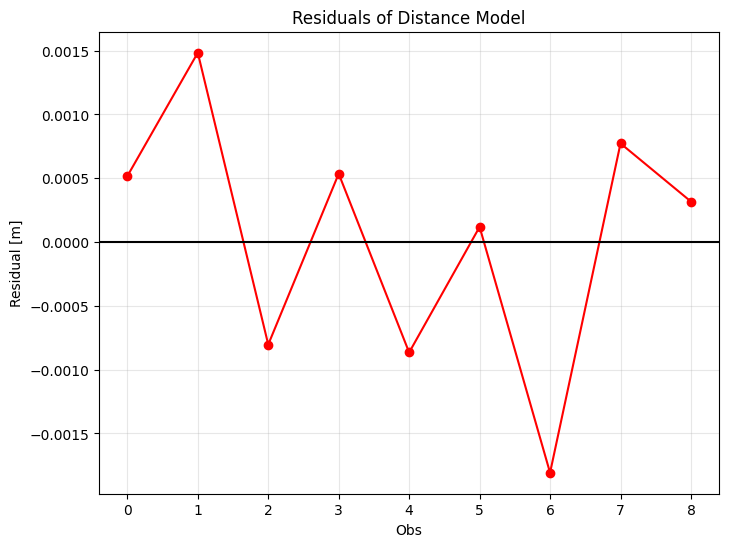

In [7]:
resCoords = pd.read_table('v_hat_coords.txt')

plt.figure(figsize=(8,6))
plt.plot(resCoords, 'ro-')
plt.axhline(y=0, color='k')
plt.xlabel('Obs'); plt.ylabel('Residual [m]'); plt.title('Residuals of Distance Model')
plt.grid(True, alpha=.3); plt.show()

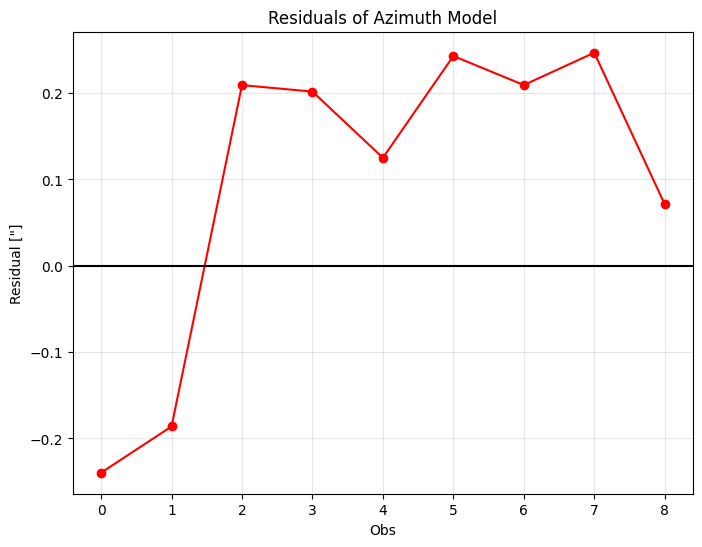

In [8]:
resAz = pd.read_table('v_hat_az.txt')
resAzDdeg = np.rad2deg(resAz)
resAzDMS = resAz*3600

plt.figure(figsize=(8,6))
plt.plot(resAzDMS, 'ro-')
plt.axhline(y=0, color='k')
plt.xlabel('Obs'); plt.ylabel('Residual ["]'); plt.title('Residuals of Azimuth Model')
plt.grid(True, alpha=.3); plt.show()

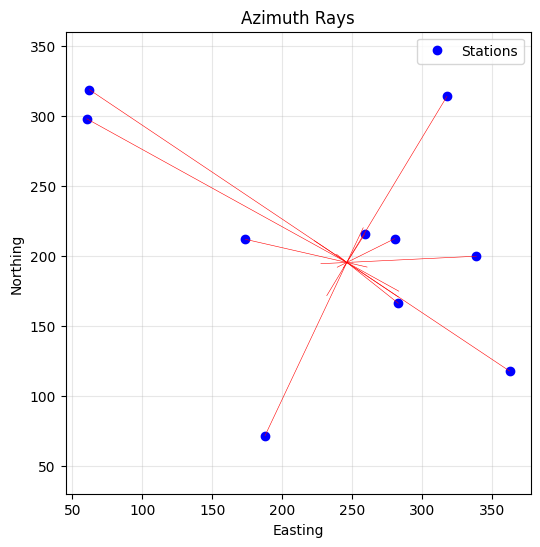

In [7]:
plt.figure(figsize=(6,6))
plt.plot(x, y, 'bo', label='Stations')
#L = 100  # length (adjust if needed)
az_rad_plot = az_rad + np.pi

for i in range(len(az_rad_plot)):
    L = r[i]*1.2
    dE = L * np.sin(az_rad_plot[i])
    dN = L * np.cos(az_rad_plot[i])
    plt.plot([x[i], x[i] + dE], [y[i], y[i] + dN], 'r-', linewidth=.4)
plt.xlabel('Easting');plt.ylabel('Northing')
plt.title('Azimuth Rays')
plt.grid(True, alpha=.3);plt.legend()
plt.axis('equal'); plt.show()